# 03 — Modèles Baseline

## Objectif
Établir des modèles de référence simples avant de passer aux modèles avancés.

Un bon modèle avancé doit **obligatoirement** surpasser ces baselines.
Si ce n'est pas le cas, le modèle avancé est inutile ou mal configuré.

## Baselines qu'on va tester

| Modèle | Description |
|--------|-------------|
| Naïf saisonnier | La prévision = valeur de la même heure hier |
| Moyenne mobile | La prévision = moyenne des 24 dernières heures |
| Régression linéaire | Modèle linéaire sur toutes les features |

## Métrique principale : MAPE
Mean Absolute Percentage Error — l'erreur moyenne en pourcentage.
Notre objectif final : **MAPE < 3%**

$$MAPE = \frac{1}{n} \sum \left| \frac{y_{réel} - y_{prédit}}{y_{réel}} \right| \times 100$$

In [1]:
# ============================================================
# 03 — MODÈLES BASELINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8')
%matplotlib inline

# Chargement du dataset final
df = pd.read_csv('../data/processed/pjme_final.csv',
                 index_col='Datetime',
                 parse_dates=True)

print(" Données chargées")
print(f"Shape : {df.shape}")
print(f"Période : {df.index.min()} → {df.index.max()}")

 Données chargées
Shape : (136630, 35)
Période : 2002-12-31 03:00:00 → 2018-08-03 00:00:00


## Découpage Train / Validation / Test

Pour une série temporelle, on respecte **obligatoirement l'ordre chronologique**.

| Set | Période | Taille | Rôle |
|-----|---------|--------|------|
| Train | 2003 à 2015 | ~78% | Entraînement |
| Validation | 2016 à 2017 | ~14% | Optimisation des hyperparamètres |
| Test | 2018 | ~8% | Évaluation finale |

Le set de test ne sera utilisé qu'une seule fois, à la toute fin 
du projet, pour comparer tous les modèles entre eux.

In [2]:
# ============================================================
# Split Train / Validation / Test
# ============================================================

FEATURES = [col for col in df.columns if col != 'PJME']
TARGET = 'PJME'

# Dates de découpage
split_train_val = '2016-01-01'
split_val_test  = '2018-01-01'

# Découpage
train = df[df.index < split_train_val]
val   = df[(df.index >= split_train_val) & (df.index < split_val_test)]
test  = df[df.index >= split_val_test]

# Features et cibles
X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train      : {train.index.min()} → {train.index.max()}")
print(f"Validation : {val.index.min()}  → {val.index.max()}")
print(f"Test       : {test.index.min()}  → {test.index.max()}")
print(f"\nTaille train      : {len(train):,} heures ({len(train)/len(df)*100:.1f}%)")
print(f"Taille validation : {len(val):,} heures ({len(val)/len(df)*100:.1f}%)")
print(f"Taille test       : {len(test):,} heures ({len(test)/len(df)*100:.1f}%)")

Train      : 2002-12-31 03:00:00 → 2015-12-31 23:00:00
Validation : 2016-01-01 00:00:00  → 2017-12-31 23:00:00
Test       : 2018-01-01 00:00:00  → 2018-08-03 00:00:00

Taille train      : 113,950 heures (83.4%)
Taille validation : 17,544 heures (12.8%)
Taille test       : 5,136 heures (3.8%)


## Métrique d'évaluation

On définit une fonction de calcul des métriques qu'on réutilisera 
pour tous les modèles du projet :

- **MAPE** : erreur moyenne en pourcentage (notre métrique principale)
- **MAE** : erreur absolue moyenne en MW
- **RMSE** : racine de l'erreur quadratique moyenne — pénalise les grosses erreurs

In [3]:
# ============================================================
# Fonction d'évaluation 
# ============================================================

def evaluer_modele(y_reel, y_pred, nom_modele):
    """Calcule et affiche les métriques d'évaluation."""
    
    mape = np.mean(np.abs((y_reel - y_pred) / y_reel)) * 100
    mae  = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))
    
    print(f"\n{'='*40}")
    print(f"  {nom_modele}")
    print(f"{'='*40}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"  MAE   : {mae:,.0f} MW")
    print(f"  RMSE  : {rmse:,.0f} MW")
    print(f"{'='*40}")
    
    return {'modele': nom_modele, 'MAPE': mape, 'MAE': mae, 'RMSE': rmse}

# Dictionnaire pour stocker les résultats de tous les modèles
resultats = {}

## 1️ Baseline : Modèle Naïf Saisonnier

On choisi ce modèle comme le point de référence minimal ie que tout autre modèle doit faire mieux que ça.

La prévision pour H+1 est simplement la valeur observée **à la même heure hier** (lag_24).




  Naïf Saisonnier (lag_24)
  MAPE  : 6.78%
  MAE   : 2,125 MW
  RMSE  : 2,917 MW


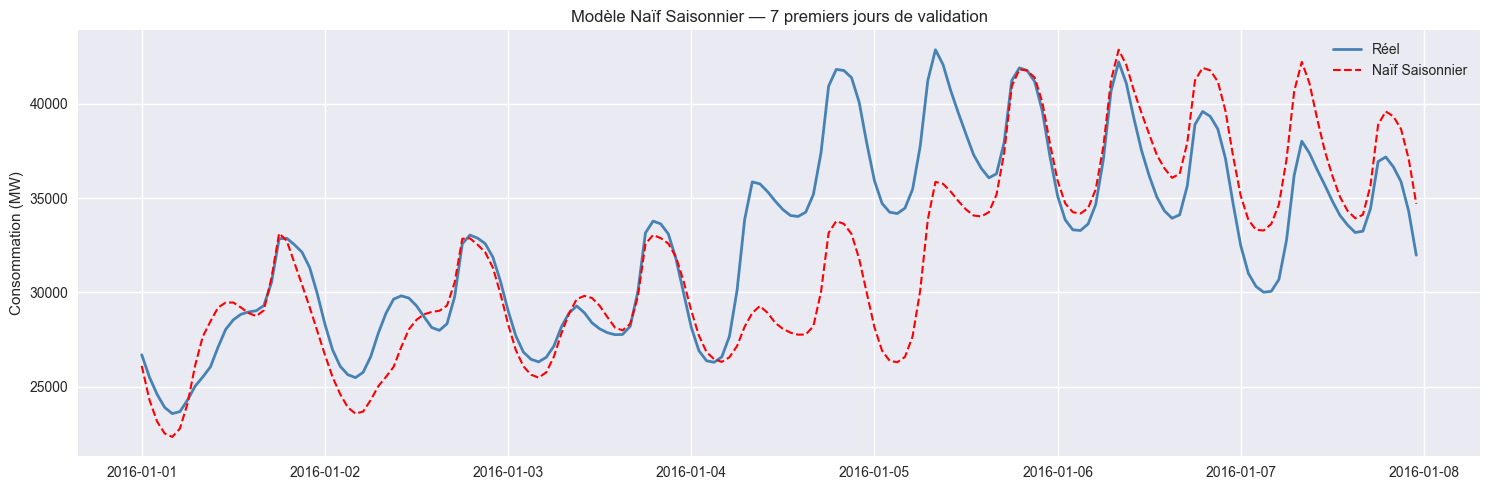

In [4]:
# ============================================================
# Baseline 1 : Modèle Naïf Saisonnier (lag_24)
# ============================================================

# La prévision = valeur de la même heure hier
y_pred_naif = X_val['lag_24']

resultats['Naïf Saisonnier'] = evaluer_modele(
    y_val, y_pred_naif, 'Naïf Saisonnier (lag_24)'
)

# Visualisation sur 7 jours
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_val[:168].index, y_val[:168].values, 
        label='Réel', color='steelblue', linewidth=2)
ax.plot(y_val[:168].index, y_pred_naif[:168].values, 
        label='Naïf Saisonnier', color='red', 
        linewidth=1.5, linestyle='--')
ax.set_title('Modèle Naïf Saisonnier — 7 premiers jours de validation')
ax.set_ylabel('Consommation (MW)')
ax.legend()
plt.tight_layout()
plt.show()

Le MAPE est de 6.78%. c'est notre baseline minimale. Tout modèle qu'on construira doit faire mieux que ça.
Sur le graphique, on voit clairement que le modèle naïf suit la bonne forme générale mais avec un décalage d'un jour. Il rate les changements brusques (mercredi 6 janvier par exemple).

## 2️ Baseline : Moyenne Mobile 24h

La prévision est la moyenne des 24 dernières heures. Ce modèle lisse les variations et capture la tendance récente, mais peut rate les pics et creux importants.


  Moyenne Mobile 24h
  MAPE  : 11.71%
  MAE   : 3,543 MW
  RMSE  : 4,438 MW


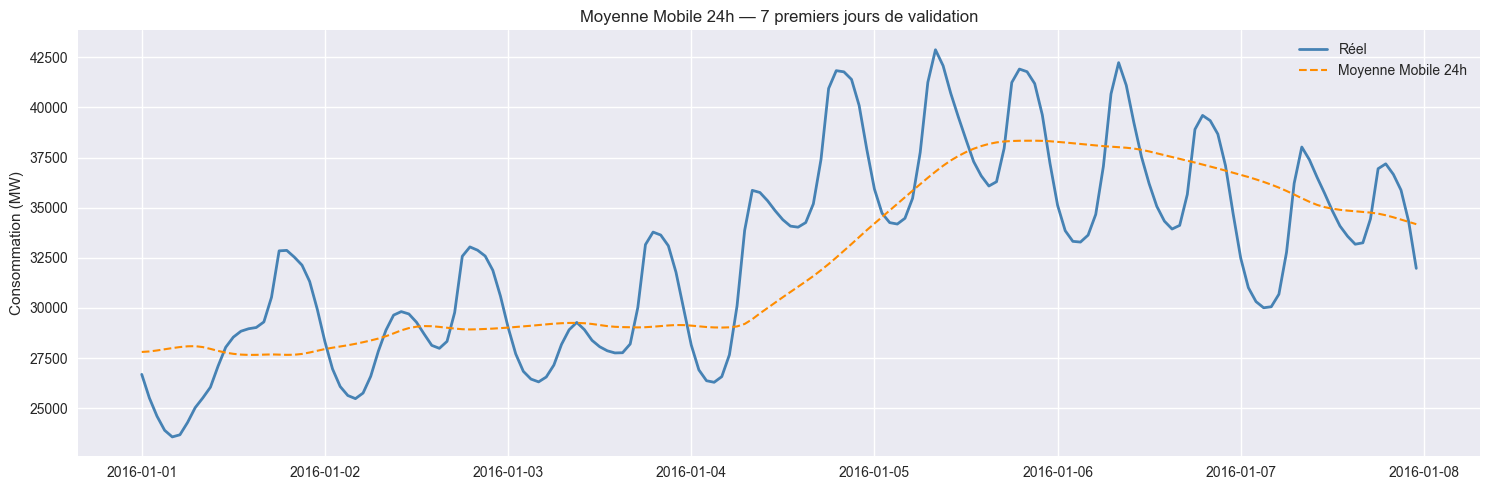

In [5]:
# ============================================================
# Baseline 2 : Moyenne Mobile 24h
# ============================================================

y_pred_mm = X_val['rolling_mean_24h']

resultats['Moyenne Mobile'] = evaluer_modele(
    y_val, y_pred_mm, 'Moyenne Mobile 24h'
)

# Visualisation sur 7 jours
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_val[:168].index, y_val[:168].values,
        label='Réel', color='steelblue', linewidth=2)
ax.plot(y_val[:168].index, y_pred_mm[:168].values,
        label='Moyenne Mobile 24h', color='darkorange',
        linewidth=1.5, linestyle='--')
ax.set_title('Moyenne Mobile 24h — 7 premiers jours de validation')
ax.set_ylabel('Consommation (MW)')
ax.legend()
plt.tight_layout()
plt.show()

MAPE de 11.71%, c'est pire que le naïf saisonnier (6.78%). Le graphique montre que la moyenne mobile lisse trop les données et rate complètement les cycles journaliers. Elle ne voit qu'une tendance générale alors que la consommation oscille fortement chaque jour.

## 3️ Baseline : Régression Linéaire


  Régression Linéaire
  MAPE  : 2.55%
  MAE   : 797 MW
  RMSE  : 1,015 MW


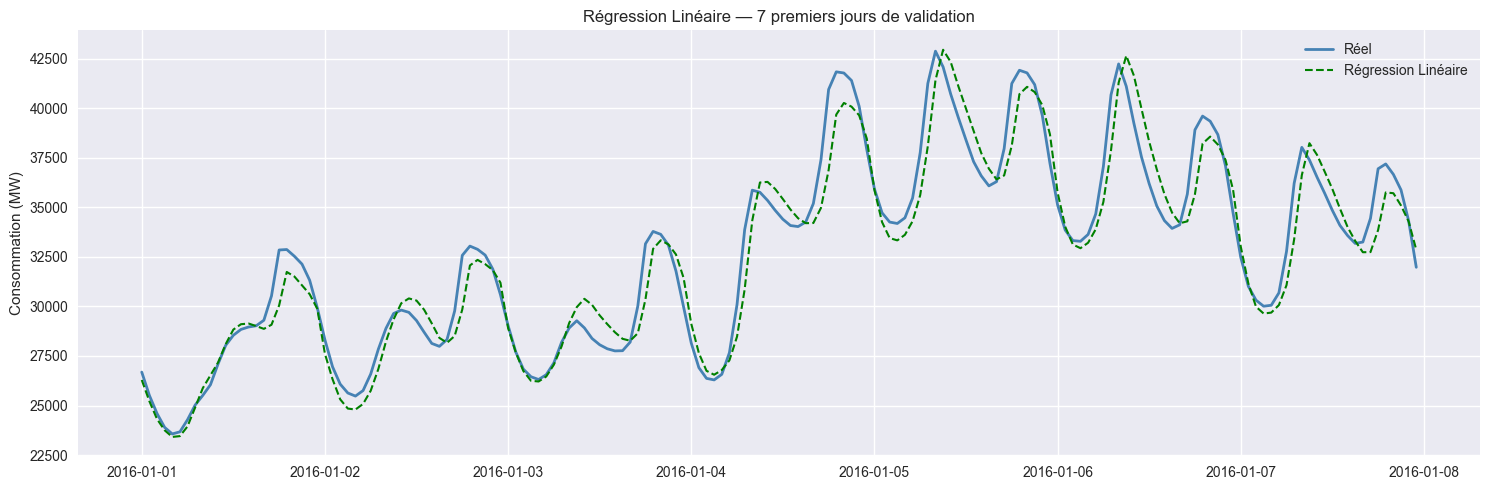

In [6]:
# ============================================================
# Baseline 3 : Régression Linéaire
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Normalisation 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Entraînement
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Prédiction
y_pred_lr = lr.predict(X_val_scaled)

resultats['Régression Linéaire'] = evaluer_modele(
    y_val, y_pred_lr, 'Régression Linéaire'
)

# Visualisation sur 7 jours
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_val[:168].index, y_val[:168].values,
        label='Réel', color='steelblue', linewidth=2)
ax.plot(y_val[:168].index, y_pred_lr[:168],
        label='Régression Linéaire', color='green',
        linewidth=1.5, linestyle='--')
ax.set_title('Régression Linéaire — 7 premiers jours de validation')
ax.set_ylabel('Consommation (MW)')
ax.legend()
plt.tight_layout()
plt.show()

MAPE de 2.55% < 3%, la régression linéaire atteint déjà notre objectif de MAPE et visuellement, le suivi est remarquablement bon.
Le feature engineering est donc très bon. La relation entre nos features et la cible est suffisamment bien capturée même par un modèle linéaire simple.

=== COMPARAISON DES BASELINES ===
                                       modele       MAPE          MAE         RMSE
Régression Linéaire       Régression Linéaire   2.554841   797.467308  1015.095332
Naïf Saisonnier      Naïf Saisonnier (lag_24)   6.776782  2124.602656  2916.880994
Moyenne Mobile             Moyenne Mobile 24h  11.707166  3542.889654  4438.366852


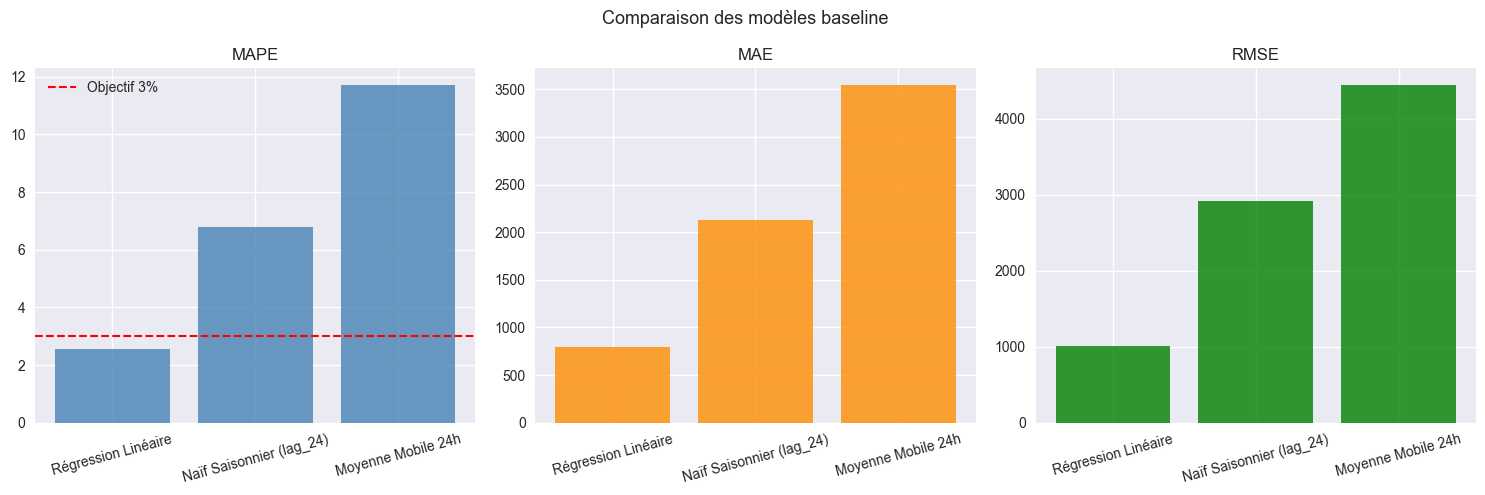

In [7]:
# ============================================================
# Comparaison de tous les modèles baseline
# ============================================================

df_resultats = pd.DataFrame(resultats).T
df_resultats = df_resultats.sort_values('MAPE')

print("=== COMPARAISON DES BASELINES ===")
print(df_resultats.to_string())

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metriques = ['MAPE', 'MAE', 'RMSE']
couleurs  = ['steelblue', 'darkorange', 'green']

for i, (metrique, couleur) in enumerate(zip(metriques, couleurs)):
    vals = df_resultats[metrique].astype(float)
    axes[i].bar(df_resultats['modele'], vals, color=couleur, alpha=0.8)
    axes[i].set_title(f'{metrique}')
    axes[i].tick_params(axis='x', rotation=15)
    if metrique == 'MAPE':
        axes[i].axhline(y=3, color='red', linestyle='--', 
                        linewidth=1.5, label='Objectif 3%')
        axes[i].legend()

plt.suptitle('Comparaison des modèles baseline', fontsize=13)
plt.tight_layout()
plt.show()

La régression linéaire atteint déjà l'objectif, le feature engineering est excellent. Les modèles avancés (XGBoost, LSTM) devront donc faire mieux en théorie.